# 04b - Inference Pipeline Test (Skeleton-Only Model)

**RAPP Lab 04 - Temporal Ensemble for Smooth Robot Control**

Alternate version of `04_inference_test.ipynb` for the **skeleton-only model** trained in `03b_train_vam_skeleton_only.ipynb`.

**Key difference:** The model takes only skeleton input `[B, T_in, 54]` — no robot joint angles in the input. This means:
- `InputAssembler` only buffers skeleton frames (ignores joint state)
- `ModelWrapper` loads `SkeletonOnlyACT` instead of `ActionChunkingTransformer`
- Everything else (TemporalEnsemble, TM12SSafetyChecker, visualization) is identical

---

**Input:** Skeleton-only model checkpoint + preprocessed data tensors  
**Output:** Validated inference pipeline + optimal ensemble parameters

## 1. Setup

In [1]:
import sys
import time
from pathlib import Path

workspace_dir = Path('/workspace')
if str(workspace_dir) not in sys.path:
    sys.path.insert(0, str(workspace_dir))

import json
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from vam_utils.config import InferenceConfig, ModelConfig
from vam_utils.config.data_config import DataPipelineConfig
from vam_utils.data import NormalizationStats, inverse_normalize_joints
from vam_utils.data.robot_configs import TM12S_JOINT_LIMITS
from vam_utils.data.normalization import apply_normalization
from vam_utils.inference import TemporalEnsemble
from vam_utils.inference.tm12s_safety_checker import TM12SSafetyChecker

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'  GPU: {torch.cuda.get_device_name()}')

print('\nImports successful!')

Device: cuda
  GPU: NVIDIA GeForce RTX 5070 Laptop GPU

Imports successful!


## 1b. Skeleton-Only Components

Define the `SkeletonOnlyACT` model and custom `InputAssembler` / `ModelWrapper` that work with skeleton-only input (54-dim instead of 54-dim).

In [2]:
class SkeletonOnlyACT(nn.Module):
    """Action Chunking Transformer — skeleton-only input variant.
    Must match the architecture in 03b_train_vam_skeleton_only.ipynb.
    """

    def __init__(self, config: ModelConfig):
        super().__init__()
        self.config = config
        self.skeleton_proj = nn.Linear(config.skeleton_dim, config.d_model)
        self.encoder_pos = nn.Embedding(config.T_in, config.d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.d_model, nhead=config.n_heads,
            dim_feedforward=config.d_ff, dropout=config.dropout,
            activation='gelu', batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=config.n_encoder_layers,
            norm=nn.LayerNorm(config.d_model),
        )

        self.action_queries = nn.Embedding(config.T_out, config.d_model)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=config.d_model, nhead=config.n_heads,
            dim_feedforward=config.d_ff, dropout=config.dropout,
            activation='gelu', batch_first=True, norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(
            decoder_layer, num_layers=config.n_decoder_layers,
            norm=nn.LayerNorm(config.d_model),
        )

        self.output_proj = nn.Linear(config.d_model, config.joint_dim)
        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if param.dim() > 1:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
        nn.init.normal_(self.encoder_pos.weight, std=0.02)
        nn.init.normal_(self.action_queries.weight, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.shape[0]
        skel_emb = self.skeleton_proj(x)
        positions = torch.arange(self.config.T_in, device=x.device)
        skel_emb = skel_emb + self.encoder_pos(positions)
        memory = self.encoder(skel_emb)
        queries = self.action_queries.weight.unsqueeze(0).expand(B, -1, -1)
        decoded = self.decoder(queries, memory)
        return self.output_proj(decoded)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print('SkeletonOnlyACT defined')

SkeletonOnlyACT defined


In [3]:
class SkeletonOnlyInputAssembler:
    """Input assembler that only buffers skeleton frames (no joint state).

    Returns [1, T_in, 54] normalized skeleton tensor.
    Joint state is still accepted via add_frame() for API compatibility
    but is ignored.
    """

    def __init__(self, norm_stats: NormalizationStats, T_in: int = 10):
        self.norm_stats = norm_stats
        self.T_in = T_in
        self._skeleton_buffer: deque = deque(maxlen=T_in)

    def add_frame(self, skeleton: np.ndarray, joints: np.ndarray = None) -> None:
        """Add a single frame. joints argument is accepted but ignored."""
        self._skeleton_buffer.append(skeleton.astype(np.float32))

    def is_ready(self) -> bool:
        return len(self._skeleton_buffer) == self.T_in

    @property
    def buffer_fill(self) -> int:
        return len(self._skeleton_buffer)

    def get_input_tensor(self) -> torch.Tensor:
        """Build normalized input tensor — skeleton only.

        Returns:
            torch.Tensor of shape [1, T_in, 54]
        """
        if not self.is_ready():
            raise RuntimeError(
                f'Buffer not ready: {self.buffer_fill}/{self.T_in} frames'
            )

        skeleton = np.stack(list(self._skeleton_buffer))  # [T_in, 54]
        skel_normed = (
            (skeleton - self.norm_stats.skeleton_mean) / self.norm_stats.skeleton_std
        )
        return torch.from_numpy(skel_normed).float().unsqueeze(0)  # [1, T_in, 54]

    def reset(self) -> None:
        self._skeleton_buffer.clear()


print('SkeletonOnlyInputAssembler defined')

SkeletonOnlyInputAssembler defined


In [4]:
class SkeletonOnlyModelWrapper:
    """Model wrapper for skeleton-only ACT inference.

    Same interface as VAMModelWrapper but loads SkeletonOnlyACT.
    Input: [1, T_in, 54] (skeleton only)
    Output: [T_out, 6] joint angles in radians
    """

    def __init__(self, config: InferenceConfig):
        self.device = torch.device(config.device)

        self.model_config = ModelConfig.load(config.model_config_path)
        self.model = SkeletonOnlyACT(self.model_config)

        checkpoint = torch.load(
            config.checkpoint_path,
            map_location=self.device,
            weights_only=False,
        )
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.to(self.device)
        self.model.eval()

        self.norm_stats = NormalizationStats.load(config.norm_stats_path)
        self.clamp_to_limits = config.clamp_to_joint_limits

        epoch = checkpoint.get('epoch', '?')
        val_loss = checkpoint.get('best_val_loss', '?')
        print(
            f'SkeletonOnlyACT loaded: {self.model.count_parameters():,} params, '
            f'epoch {epoch}, val_loss {val_loss}'
        )

    @torch.inference_mode()
    def predict(self, input_tensor: torch.Tensor) -> np.ndarray:
        """Run forward pass. Input: [1, T_in, 54]. Returns: [T_out, 6] radians."""
        pred_normed = self.model(input_tensor.to(self.device))
        pred_np = pred_normed.cpu().numpy()[0]
        return inverse_normalize_joints(
            pred_np, self.norm_stats, clamp_to_limits=self.clamp_to_limits, joint_limits=TM12S_JOINT_LIMITS
        )


print('SkeletonOnlyModelWrapper defined')

SkeletonOnlyModelWrapper defined


## 2. Load Model & Data

In [5]:
# =============================================================================
# CONFIGURATION — Point to your skeleton-only trained model
# =============================================================================
DATA_DIR = Path('/data/processed/tensors/2026_02_10_tin10_tout10')

# UPDATE THIS PATH to your skeleton-only model checkpoint!
SKELONLY_MODEL_DIR = Path('/data/models')  # <-- will be auto-detected below

# Auto-detect most recent vam_skelonly_* experiment
skelonly_dirs = sorted(SKELONLY_MODEL_DIR.glob('vam_skelonly_*'))
if skelonly_dirs:
    model_dir = skelonly_dirs[-1]  # most recent
    print(f'Auto-detected skeleton-only model: {model_dir.name}')
else:
    raise FileNotFoundError(
        'No vam_skelonly_* model found. Run 03b_train_vam_skeleton_only.ipynb first!'
    )

inference_config = InferenceConfig(
    checkpoint_path=model_dir / 'best.pt',
    model_config_path=model_dir / 'model_config.json',
    norm_stats_path=DATA_DIR / 'norm_stats.pt',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    prediction_stride_K=2,
    ensemble_decay_weight=0.01,
    control_rate_hz=15.0,
    max_joint_velocity_rad_s=1.0,
    max_joint_acceleration_rad_s2=5.0,
)
# =============================================================================

print('\nInference Configuration')
print('=' * 60)
print(f'  Checkpoint:       {inference_config.checkpoint_path}')
print(f'  Device:           {inference_config.device}')
print(f'  Prediction K:     {inference_config.prediction_stride_K}')
print(f'  Decay weight:     {inference_config.ensemble_decay_weight}')
print(f'  Control rate:     {inference_config.control_rate_hz} Hz')
print(f'  Max velocity:     {inference_config.max_joint_velocity_rad_s} rad/s')
print(f'  Max acceleration: {inference_config.max_joint_acceleration_rad_s2} rad/s^2')

Auto-detected skeleton-only model: vam_skelonly_20260224_0607

Inference Configuration
  Checkpoint:       /data/models/vam_skelonly_20260224_0607/best.pt
  Device:           cuda
  Prediction K:     2
  Decay weight:     0.01
  Control rate:     15.0 Hz
  Max velocity:     1.0 rad/s
  Max acceleration: 5.0 rad/s^2


In [6]:
# Load the skeleton-only model wrapper
model = SkeletonOnlyModelWrapper(inference_config)

# Load normalization stats
norm_stats = NormalizationStats.load(inference_config.norm_stats_path)

# Load data pipeline config
data_config = DataPipelineConfig.load(DATA_DIR / 'pipeline_config.json')
T_in = data_config.T_in
T_out = data_config.T_out

print(f'\nModel loaded successfully')
print(f'T_in={T_in}, T_out={T_out}')

SkeletonOnlyACT loaded: 1,134,086 params, epoch 20, val_loss 2.952238424275166

Model loaded successfully
T_in=10, T_out=10


/tmp/ipykernel_2155/3781423633.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


In [7]:
# Load episode tensors and split info
episode_data = {}
ep_dir = DATA_DIR / 'episodes'
for ep_file in sorted(ep_dir.glob('*.pt')):
    ep_id = ep_file.stem
    episode_data[ep_id] = torch.load(ep_file, weights_only=False)
print(f'Loaded {len(episode_data)} episodes')

with open(DATA_DIR / 'splits.json') as f:
    splits_dict = json.load(f)
print(f'Test episodes: {splits_dict["test"]}')

# Pick first test episode for detailed analysis
test_ep_id = splits_dict['test'][0]
test_ep = episode_data[test_ep_id]
n_frames = test_ep['skeleton'].shape[0]
print(f'\nUsing test episode: {test_ep_id}')
print(f'  Frames: {n_frames}')
print(f'  Skeleton: {test_ep["skeleton"].shape}')
print(f'  Joints:   {test_ep["joints"].shape}')

Loaded 10 episodes
Test episodes: ['25_12_11_RAPP_M_R2G1S1_02', '25_12_11_RAPP_M_R2G5S1_01']

Using test episode: 25_12_11_RAPP_M_R2G1S1_02
  Frames: 1191
  Skeleton: (1191, 48)
  Joints:   (1191, 6)


## 3. Full Pipeline Simulation

Replay the test episode frame-by-frame through the skeleton-only inference pipeline:

```
CSV frame → SkeletonOnlyInputAssembler → SkeletonOnlyModelWrapper → TemporalEnsemble → TM12SSafetyChecker → output
```

Note: The assembler only uses skeleton data. Joint state from the episode is used solely for ground truth comparison.

In [8]:
def run_inference_pipeline(
    episode_data_dict,
    model_wrapper,
    norm_stats,
    K=2,
    decay_weight=0.01,
    max_vel=1.0,
    max_acc=5.0,
    dt=1/15.0,
    T_in=10,
    T_out=10,
    collect_raw_chunks=False,
):
    """
    Run the full inference pipeline on a single episode using skeleton-only input.
    """
    skeleton_raw = episode_data_dict['skeleton']
    joints_raw = episode_data_dict['joints']
    skeleton = skeleton_raw.numpy() if hasattr(skeleton_raw, 'numpy') else np.asarray(skeleton_raw)
    joints = joints_raw.numpy() if hasattr(joints_raw, 'numpy') else np.asarray(joints_raw)
    n_frames = skeleton.shape[0]

    # Use skeleton-only assembler
    assembler = SkeletonOnlyInputAssembler(norm_stats, T_in=T_in)
    ensemble = TemporalEnsemble(T_out=T_out, K=K, decay_weight=decay_weight)
    safety = TM12SSafetyChecker(
        max_joint_velocity_rad_s=max_vel,
        max_joint_acceleration_rad_s2=max_acc,
        dt=dt,
    )

    ensemble_out = []
    gt_out = []
    all_warnings = []
    n_predictions = 0
    n_constrained = 0
    raw_chunks = [] if collect_raw_chunks else None

    for i in range(n_frames):
        # Feed skeleton frame only (joints ignored by assembler)
        assembler.add_frame(skeleton[i])

        if not assembler.is_ready():
            continue

        if ensemble.should_predict():
            input_tensor = assembler.get_input_tensor()  # [1, T_in, 54]
            chunk = model_wrapper.predict(input_tensor)  # [T_out, 6] radians
            ensemble.add_prediction(chunk)
            n_predictions += 1
            if collect_raw_chunks:
                raw_chunks.append((ensemble.global_step, chunk.copy()))

        if ensemble.num_predictions > 0:
            target = ensemble.query()
            report = safety.check(target)
            ensemble_out.append(report.target)

            gt_idx = i + T_out
            if gt_idx < n_frames:
                gt_out.append(joints[gt_idx])
            else:
                gt_out.append(joints[-1])

            if report.warnings:
                all_warnings.extend(report.warnings)
            if report.was_constrained:
                n_constrained += 1

        ensemble.step()

    return {
        'ensemble_trajectory': np.array(ensemble_out),
        'gt_trajectory': np.array(gt_out),
        'safety_warnings': all_warnings,
        'n_predictions': n_predictions,
        'n_constrained': n_constrained,
        'raw_chunks': raw_chunks,
    }

In [9]:
# Run with default parameters
print(f'Running skeleton-only pipeline on episode {test_ep_id} ({n_frames} frames)...')
print(f'  K={inference_config.prediction_stride_K}, lambda={inference_config.ensemble_decay_weight}')

t_start = time.perf_counter()
results = run_inference_pipeline(
    test_ep,
    model,
    norm_stats,
    K=inference_config.prediction_stride_K,
    decay_weight=inference_config.ensemble_decay_weight,
    max_vel=inference_config.max_joint_velocity_rad_s,
    max_acc=inference_config.max_joint_acceleration_rad_s2,
    collect_raw_chunks=True,
)
t_elapsed = time.perf_counter() - t_start

print(f'\nPipeline complete in {t_elapsed:.2f}s')
print(f'  Output frames:    {len(results["ensemble_trajectory"])}')
print(f'  Model predictions: {results["n_predictions"]}')
print(f'  Safety constrained: {results["n_constrained"]} frames')
if results['safety_warnings']:
    unique_warnings = set(w.split(':')[0] for w in results['safety_warnings'])
    print(f'  Warning types: {unique_warnings}')
    print(f'  Total warnings: {len(results["safety_warnings"])}')

Running skeleton-only pipeline on episode 25_12_11_RAPP_M_R2G1S1_02 (1191 frames)...
  K=2, lambda=0.01

Pipeline complete in 0.76s
  Output frames:    1182
  Model predictions: 591
  Safety constrained: 571 frames
  Warning types: {'Velocity limited', 'Acceleration limited'}
  Total warnings: 645


## 4. Ensemble vs Ground Truth Visualization

Compare the temporal ensemble output against ground truth joint trajectories.

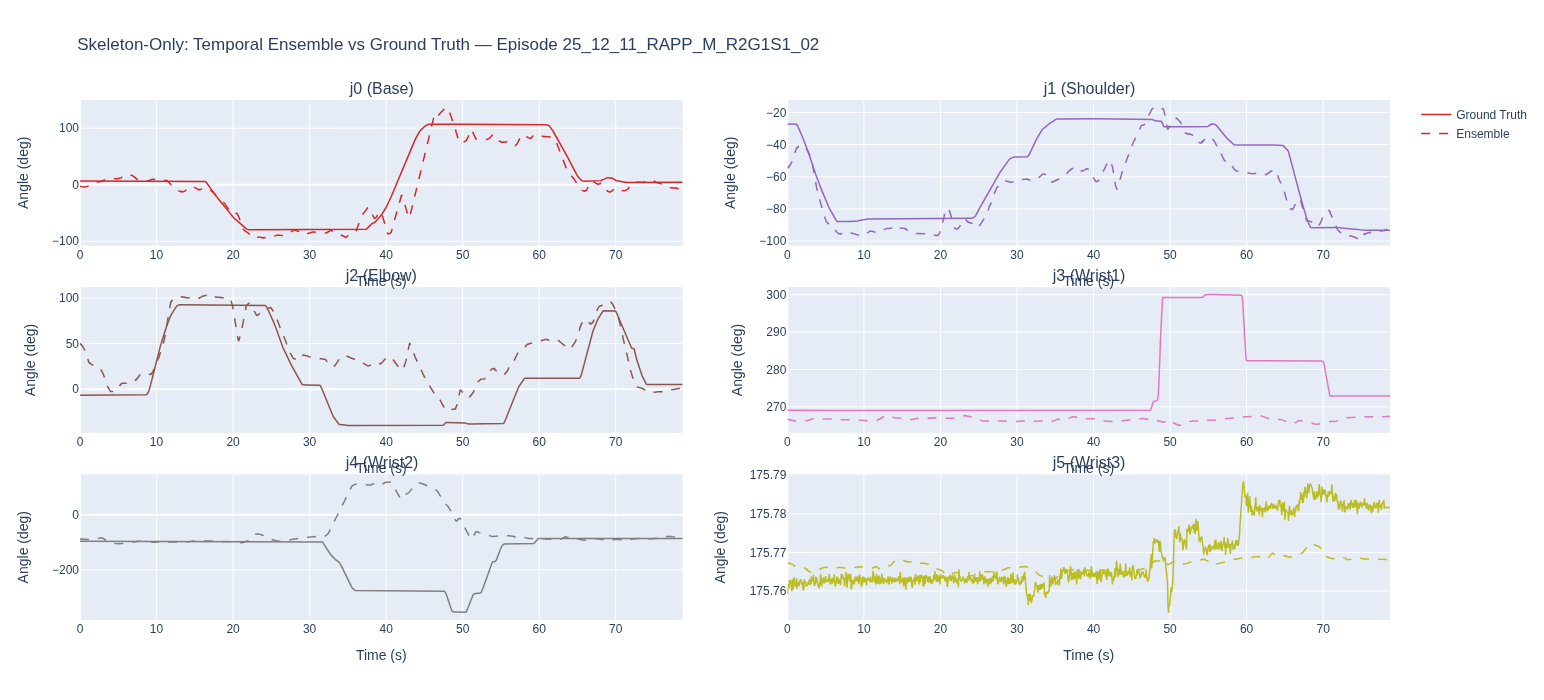


Per-joint RMSE (ensemble vs GT):
  j0 (Base): 24.25 deg (0.4232 rad)
  j1 (Shoulder): 16.49 deg (0.2877 rad)
  j2 (Elbow): 37.72 deg (0.6583 rad)
  j3 (Wrist1): 13.98 deg (0.2440 rad)
  j4 (Wrist2): 172.13 deg (3.0042 rad)
  j5 (Wrist3): 0.01 deg (0.0001 rad)


In [10]:
ensemble_traj = results['ensemble_trajectory']
gt_traj = results['gt_trajectory']

n_output = len(ensemble_traj)
time_axis = np.arange(n_output) / 15.0

joint_names = ['j0 (Joint 1)', 'j1 (Joint 2)', 'j2 (Joint 3)',
               'j3 (Joint 4)', 'j4 (Joint 5)', 'j5 (Joint 6)']
colors = ['#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22']

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=joint_names,
    horizontal_spacing=0.08,
    vertical_spacing=0.08,
)

for j in range(6):
    row, col = j // 2 + 1, j % 2 + 1

    fig.add_trace(go.Scatter(
        x=time_axis, y=np.degrees(gt_traj[:, j]),
        name='Ground Truth' if j == 0 else None,
        mode='lines', line=dict(color=colors[j], width=1.5),
        showlegend=(j == 0),
    ), row=row, col=col)

    fig.add_trace(go.Scatter(
        x=time_axis, y=np.degrees(ensemble_traj[:, j]),
        name='Ensemble' if j == 0 else None,
        mode='lines', line=dict(color=colors[j], width=1.5, dash='dash'),
        showlegend=(j == 0),
    ), row=row, col=col)

fig.update_layout(
    height=700, width=1100,
    title_text=f'Skeleton-Only: Temporal Ensemble vs Ground Truth — Episode {test_ep_id}',
)
fig.update_xaxes(title_text='Time (s)')
fig.update_yaxes(title_text='Angle (deg)')
fig.show()

# Per-joint RMSE
min_len = min(len(ensemble_traj), len(gt_traj))
rmse_per_joint = np.sqrt(((ensemble_traj[:min_len] - gt_traj[:min_len]) ** 2).mean(axis=0))
print('\nPer-joint RMSE (ensemble vs GT):')
for j, name in enumerate(joint_names):
    print(f'  {name}: {np.degrees(rmse_per_joint[j]):.2f} deg ({rmse_per_joint[j]:.4f} rad)')

## 5. Visualize Overlapping Chunks

Show how individual prediction chunks overlap and how the ensemble blends them.

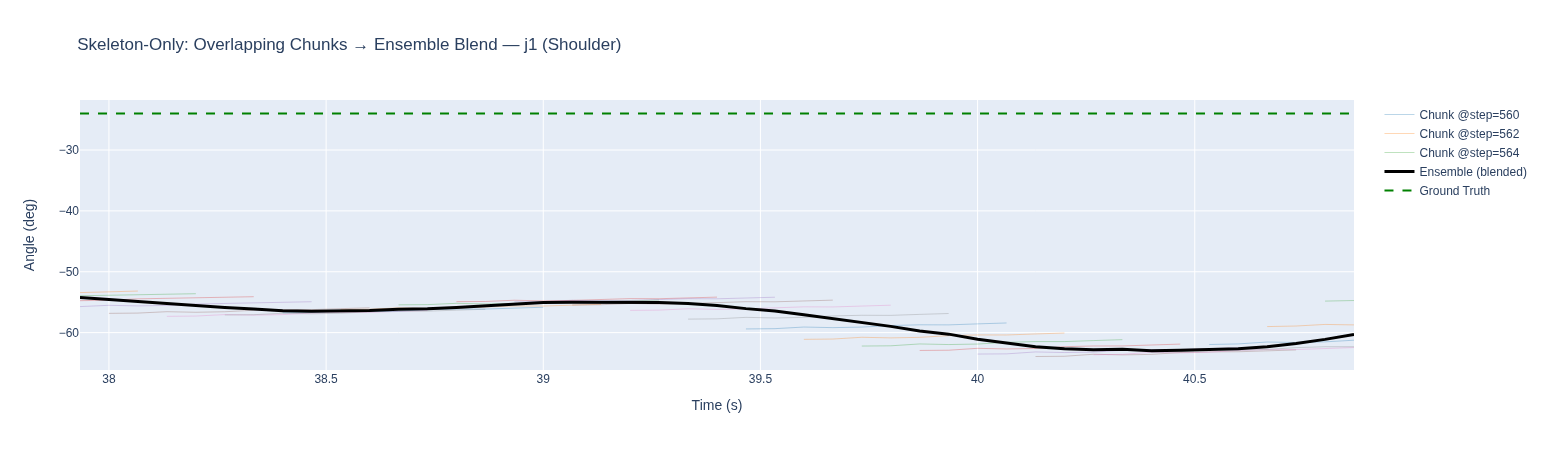

Showing 27 overlapping chunks in the window


In [11]:
JOINT_IDX = 1  # shoulder
raw_chunks = results['raw_chunks']
K = inference_config.prediction_stride_K

mid_step = len(ensemble_traj) // 2
window_start = max(0, mid_step - 22)
window_end = min(len(ensemble_traj), mid_step + 23)

fig = go.Figure()

chunk_colors = ['rgba(31,119,180,0.3)', 'rgba(255,127,14,0.3)', 'rgba(44,160,44,0.3)',
                'rgba(214,39,40,0.3)', 'rgba(148,103,189,0.3)', 'rgba(140,86,75,0.3)',
                'rgba(227,119,194,0.3)', 'rgba(127,127,127,0.3)']

chunks_plotted = 0
for step, chunk in raw_chunks:
    chunk_start = step
    chunk_end = step + T_out
    if chunk_end < window_start or chunk_start > window_end:
        continue

    t = np.arange(step, step + T_out) / 15.0
    mask = (np.arange(step, step + T_out) >= window_start) & (np.arange(step, step + T_out) < window_end)
    if not mask.any():
        continue

    color = chunk_colors[chunks_plotted % len(chunk_colors)]
    fig.add_trace(go.Scatter(
        x=t[mask], y=np.degrees(chunk[mask, JOINT_IDX]),
        mode='lines', line=dict(color=color, width=1),
        name=f'Chunk @step={step}' if chunks_plotted < 3 else None,
        showlegend=(chunks_plotted < 3),
    ))
    chunks_plotted += 1

t_ensemble = np.arange(window_start, min(window_end, len(ensemble_traj))) / 15.0
fig.add_trace(go.Scatter(
    x=t_ensemble, y=np.degrees(ensemble_traj[window_start:window_end, JOINT_IDX]),
    mode='lines', line=dict(color='black', width=3),
    name='Ensemble (blended)',
))

fig.add_trace(go.Scatter(
    x=t_ensemble, y=np.degrees(gt_traj[window_start:window_end, JOINT_IDX]),
    mode='lines', line=dict(color='green', width=2, dash='dash'),
    name='Ground Truth',
))

fig.update_layout(
    title=f'Skeleton-Only: Overlapping Chunks → Ensemble Blend — {joint_names[JOINT_IDX]}',
    xaxis_title='Time (s)', yaxis_title='Angle (deg)',
    height=450, width=1000,
)
fig.show()
print(f'Showing {chunks_plotted} overlapping chunks in the window')

## 6. Smoothness Analysis

Compare velocity and acceleration profiles of ensemble output vs ground truth.

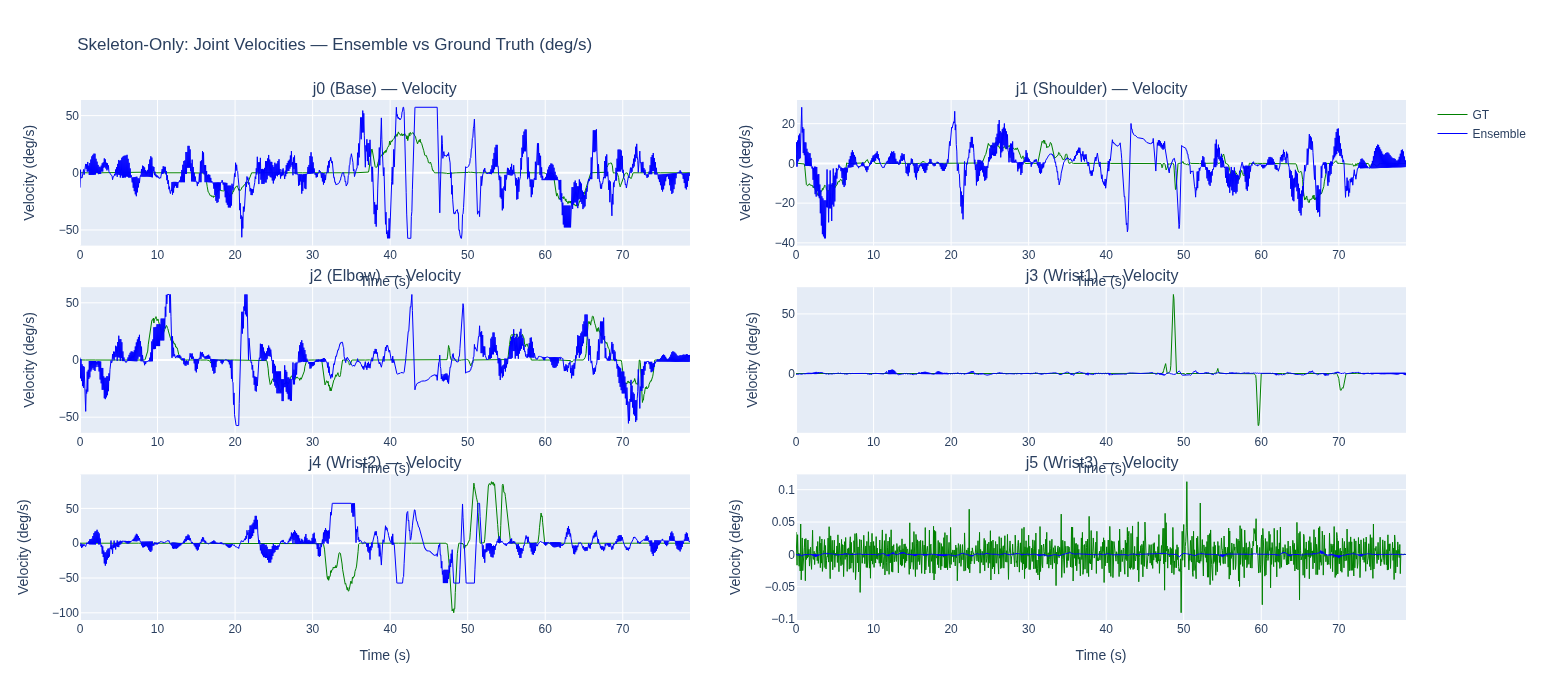


Smoothness Metrics (lower = smoother):
                       Ensemble           GT
---------------------------------------------
j0 (Base)                 165.4         12.9 deg/s^2 (std of acc)
j1 (Shoulder)              90.8          9.9 deg/s^2 (std of acc)
j2 (Elbow)                150.5         21.1 deg/s^2 (std of acc)
j3 (Wrist1)                11.8         22.5 deg/s^2 (std of acc)
j4 (Wrist2)               134.2         46.4 deg/s^2 (std of acc)
j5 (Wrist3)                 0.0          0.5 deg/s^2 (std of acc)


In [12]:
dt = 1.0 / 15.0

ensemble_vel = np.diff(np.degrees(ensemble_traj), axis=0) / dt
gt_vel = np.diff(np.degrees(gt_traj), axis=0) / dt

ensemble_acc = np.diff(ensemble_vel, axis=0) / dt
gt_acc = np.diff(gt_vel, axis=0) / dt

t_vel = np.arange(len(ensemble_vel)) / 15.0
t_acc = np.arange(len(ensemble_acc)) / 15.0

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[f'{name} — Velocity' for name in joint_names],
    horizontal_spacing=0.08,
    vertical_spacing=0.08,
)

for j in range(6):
    row, col = j // 2 + 1, j % 2 + 1
    fig.add_trace(go.Scatter(
        x=t_vel, y=gt_vel[:, j],
        name='GT' if j == 0 else None,
        mode='lines', line=dict(color='green', width=1),
        showlegend=(j == 0),
    ), row=row, col=col)
    fig.add_trace(go.Scatter(
        x=t_vel, y=ensemble_vel[:, j],
        name='Ensemble' if j == 0 else None,
        mode='lines', line=dict(color='blue', width=1),
        showlegend=(j == 0),
    ), row=row, col=col)

fig.update_layout(
    height=700, width=1100,
    title_text='Skeleton-Only: Joint Velocities — Ensemble vs Ground Truth (deg/s)',
)
fig.update_xaxes(title_text='Time (s)')
fig.update_yaxes(title_text='Velocity (deg/s)')
fig.show()

print('\nSmoothness Metrics (lower = smoother):')
print(f'{"":<18} {"Ensemble":>12} {"GT":>12}')
print('-' * 45)
for j, name in enumerate(joint_names):
    ens_jerk = np.std(ensemble_acc[:, j])
    gt_jerk = np.std(gt_acc[:, j])
    print(f'{name:<18} {ens_jerk:>12.1f} {gt_jerk:>12.1f} deg/s^2 (std of acc)')

## 7. Parameter Sweep

Vary K (prediction stride) and λ (decay weight) to find the optimal tradeoff.

In [13]:
K_values = [1, 2, 3, 5]
lambda_values = [0.01, 0.05, 0.1, 0.5]

sweep_results = []

print('Running parameter sweep (skeleton-only model)...')
for K in K_values:
    for lam in lambda_values:
        res = run_inference_pipeline(
            test_ep, model, norm_stats,
            K=K, decay_weight=lam,
            max_vel=10.0,
            max_acc=100.0,
        )

        ens = res['ensemble_trajectory']
        gt = res['gt_trajectory']
        min_len = min(len(ens), len(gt))

        rmse = np.sqrt(((ens[:min_len] - gt[:min_len]) ** 2).mean())
        rmse_deg = np.degrees(rmse)

        vel = np.diff(ens, axis=0) / dt
        acc = np.diff(vel, axis=0) / dt
        acc_std = np.std(acc)
        acc_std_deg = np.degrees(acc_std)

        sweep_results.append({
            'K': K, 'lambda': lam,
            'rmse_deg': rmse_deg,
            'acc_std_deg': acc_std_deg,
            'n_predictions': res['n_predictions'],
        })
        print(f'  K={K}, \u03bb={lam:.2f} \u2192 RMSE={rmse_deg:.2f}\u00b0 | Acc std={acc_std_deg:.1f}\u00b0/s\u00b2 | {res["n_predictions"]} predictions')

print('\nSweep complete!')

Running parameter sweep (skeleton-only model)...
  K=1, λ=0.01 → RMSE=72.58° | Acc std=48.9°/s² | 1182 predictions
  K=1, λ=0.05 → RMSE=72.56° | Acc std=49.6°/s² | 1182 predictions
  K=1, λ=0.10 → RMSE=72.54° | Acc std=51.7°/s² | 1182 predictions
  K=1, λ=0.50 → RMSE=72.41° | Acc std=80.8°/s² | 1182 predictions
  K=2, λ=0.01 → RMSE=72.59° | Acc std=487.6°/s² | 591 predictions
  K=2, λ=0.05 → RMSE=72.56° | Acc std=489.8°/s² | 591 predictions
  K=2, λ=0.10 → RMSE=72.54° | Acc std=495.9°/s² | 591 predictions
  K=2, λ=0.50 → RMSE=72.43° | Acc std=579.4°/s² | 591 predictions
  K=3, λ=0.01 → RMSE=72.59° | Acc std=593.7°/s² | 394 predictions
  K=3, λ=0.05 → RMSE=72.58° | Acc std=593.6°/s² | 394 predictions
  K=3, λ=0.10 → RMSE=72.56° | Acc std=595.6°/s² | 394 predictions
  K=3, λ=0.50 → RMSE=72.48° | Acc std=613.4°/s² | 394 predictions
  K=5, λ=0.01 → RMSE=72.63° | Acc std=622.1°/s² | 237 predictions
  K=5, λ=0.05 → RMSE=72.61° | Acc std=622.6°/s² | 237 predictions
  K=5, λ=0.10 → RMSE=72.58°

In [14]:
fig = go.Figure()

k_colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 5: '#d62728'}

for K in K_values:
    subset = [r for r in sweep_results if r['K'] == K]
    fig.add_trace(go.Scatter(
        x=[r['rmse_deg'] for r in subset],
        y=[r['acc_std_deg'] for r in subset],
        mode='lines+markers+text',
        name=f'K={K}',
        marker=dict(size=10, color=k_colors[K]),
        text=[f'\u03bb={r["lambda"]}' for r in subset],
        textposition='top center',
    ))

fig.update_layout(
    title='Skeleton-Only: Parameter Sweep — Accuracy vs Smoothness',
    xaxis_title='RMSE (degrees) — lower = more accurate',
    yaxis_title='Acceleration Std (deg/s\u00b2) — lower = smoother',
    height=500, width=700,
)
fig.show()

print('\nAll results sorted by RMSE:')
print(f'{"K":>3} {"\u03bb":>6} {"RMSE (deg)":>12} {"Acc std":>12} {"Predictions":>12}')
print('-' * 50)
for r in sorted(sweep_results, key=lambda x: x['rmse_deg']):
    print(f'{r["K"]:>3} {r["lambda"]:>6.2f} {r["rmse_deg"]:>12.2f} {r["acc_std_deg"]:>12.1f} {r["n_predictions"]:>12}')

SyntaxError: f-string expression part cannot include a backslash (2218580080.py, line 26)

## 8. Latency Profiling

Measure inference timing for the skeleton-only model.

In [15]:
# Build a test input using skeleton-only assembler
assembler = SkeletonOnlyInputAssembler(norm_stats, T_in=T_in)
skeleton_raw = test_ep['skeleton']
skeleton = skeleton_raw.numpy() if hasattr(skeleton_raw, 'numpy') else np.asarray(skeleton_raw)
for i in range(T_in):
    assembler.add_frame(skeleton[i])
test_input = assembler.get_input_tensor()  # [1, T_in, 54]
print(f'Test input shape: {test_input.shape}  (expected: [1, {T_in}, 54])')

# Warmup
for _ in range(10):
    _ = model.predict(test_input)

# Profile
N_RUNS = 1000
if torch.cuda.is_available():
    torch.cuda.synchronize()

latencies = []
for _ in range(N_RUNS):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = model.predict(test_input)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    latencies.append((time.perf_counter() - t0) * 1000)

latencies = np.array(latencies)

print(f'\nInference Latency ({N_RUNS} runs)')
print('=' * 40)
print(f'  Mean:   {latencies.mean():.2f} ms')
print(f'  Median: {np.median(latencies):.2f} ms')
print(f'  P95:    {np.percentile(latencies, 95):.2f} ms')
print(f'  P99:    {np.percentile(latencies, 99):.2f} ms')
print(f'  Max:    {latencies.max():.2f} ms')
print(f'\n  Budget at 15Hz: 66.7 ms per frame')
print(f'  Headroom: {66.7 - latencies.mean():.1f} ms ({(1 - latencies.mean()/66.7)*100:.0f}%)')
print(f'  Max achievable rate: {1000/latencies.mean():.0f} Hz')

Test input shape: torch.Size([1, 10, 48])  (expected: [1, 10, 48])

Inference Latency (1000 runs)
  Mean:   0.92 ms
  Median: 0.87 ms
  P95:    1.19 ms
  P99:    1.57 ms
  Max:    3.10 ms

  Budget at 15Hz: 66.7 ms per frame
  Headroom: 65.8 ms (99%)
  Max achievable rate: 1093 Hz


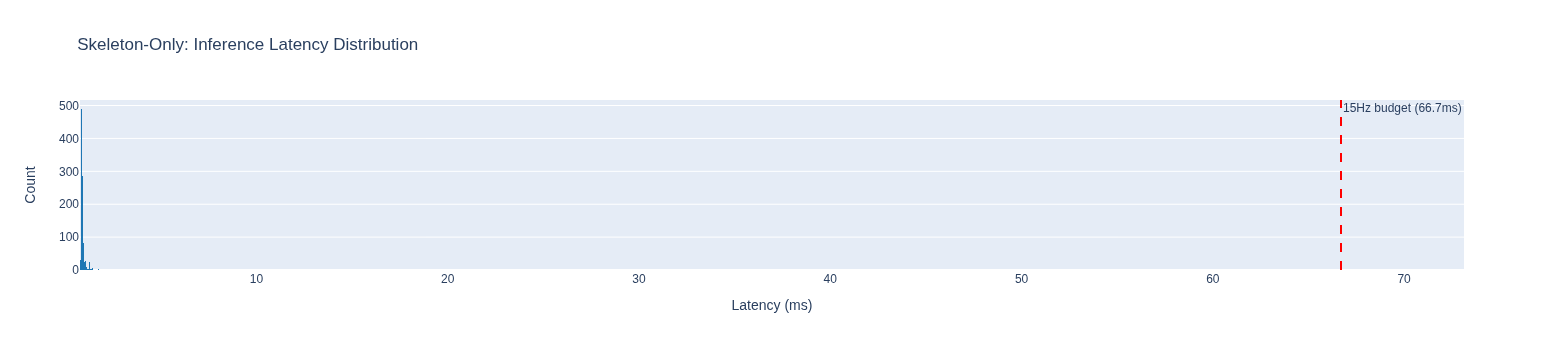

In [16]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=latencies, nbinsx=50,
    name='Inference latency',
    marker_color='#1f77b4',
))
fig.add_vline(x=66.7, line_dash='dash', line_color='red',
              annotation_text='15Hz budget (66.7ms)')
fig.update_layout(
    title='Skeleton-Only: Inference Latency Distribution',
    xaxis_title='Latency (ms)',
    yaxis_title='Count',
    height=350, width=600,
)
fig.show()

## 9. Summary

In [17]:
print('=' * 70)
print('INFERENCE PIPELINE TEST COMPLETE — SKELETON-ONLY MODEL')
print('=' * 70)

print(f'\nModel: {model_dir.name}')
print(f'Episode: {test_ep_id} ({n_frames} frames)')

print(f'\nDefault Parameters:')
print(f'  K (stride):       {inference_config.prediction_stride_K}')
print(f'  Lambda (decay):   {inference_config.ensemble_decay_weight}')
print(f'  Control rate:     {inference_config.control_rate_hz} Hz')

print(f'\nPipeline Results:')
print(f'  Output frames:    {len(results["ensemble_trajectory"])}')
print(f'  Model calls:      {results["n_predictions"]}')
print(f'  Safety constrained: {results["n_constrained"]} frames')

print(f'\nAccuracy (ensemble vs GT):')
for j, name in enumerate(joint_names):
    print(f'  {name}: {np.degrees(rmse_per_joint[j]):.2f} deg')

print(f'\nInference Latency:')
print(f'  Mean: {latencies.mean():.2f} ms')
print(f'  Max achievable rate: {1000/latencies.mean():.0f} Hz')

print(f'\n{"=" * 70}')
print('NEXT STEPS:')
print('  1. Compare these results with the original model (04_inference_test.ipynb)')
print('  2. If accuracy is acceptable, swap the model in the ROS2 inference node')
print('  3. For ROS2: use SkeletonOnlyACT + SkeletonOnlyInputAssembler')
print('  4. The skeleton-only model does NOT need joint_states feedback!')
print('=' * 70)

INFERENCE PIPELINE TEST COMPLETE — SKELETON-ONLY MODEL

Model: vam_skelonly_20260224_0607
Episode: 25_12_11_RAPP_M_R2G1S1_02 (1191 frames)

Default Parameters:
  K (stride):       2
  Lambda (decay):   0.01
  Control rate:     15.0 Hz

Pipeline Results:
  Output frames:    1182
  Model calls:      591
  Safety constrained: 571 frames

Accuracy (ensemble vs GT):
  j0 (Base): 24.25 deg
  j1 (Shoulder): 16.49 deg
  j2 (Elbow): 37.72 deg
  j3 (Wrist1): 13.98 deg
  j4 (Wrist2): 172.13 deg
  j5 (Wrist3): 0.01 deg

Inference Latency:
  Mean: 0.92 ms
  Max achievable rate: 1093 Hz

NEXT STEPS:
  1. Compare these results with the original model (04_inference_test.ipynb)
  2. If accuracy is acceptable, swap the model in the ROS2 inference node
  3. For ROS2: use SkeletonOnlyACT + SkeletonOnlyInputAssembler
  4. The skeleton-only model does NOT need joint_states feedback!
